# T-LARS 3-D Image Reconstruction with DCT + Wavelet Dictionaries

**Sparse recovery of an RGB scene using overcomplete tensor dictionaries.**

This notebook demonstrates the **Tensor Least Angle Regression and Selection (T-LARS)**
algorithm from the `tensor_ml` library applied to **3-D image reconstruction**.  A synthetic
RGB scene is treated as an order-3 tensor ($\text{rows} \times \text{cols} \times 3$)
and reconstructed using overcomplete dictionaries that combine a **DCT basis** with a
**Symlet-4 wavelet packet basis** — the same dictionary design used in the original T-LARS
paper.

### Dictionary design (matching the T-LARS paper)

| Mode | Dictionary | Size | Description |
|------|-----------|------|-------------|
| **Rows** ($D_1$) | DCT ∪ WP(sym4,3) | $M \times 2M$ | Overcomplete (2×) |
| **Columns** ($D_2$) | DCT ∪ WP(sym4,3) | $N \times 2N$ | Overcomplete (2×) |
| **Channels** ($D_3$) | Identity | $3 \times 3$ | No overcompleteness |

Here **WP(sym4, 3)** denotes a wavelet packet dictionary using the Symlet-4 wavelet
(4 vanishing moments) at decomposition level 3.

### What you will see

| Step | Description |
|------|-------------|
| **1** | Generate a synthetic RGB scene (64×64×3) |
| **2** | Build DCT + Symlet-4 wavelet packet overcomplete dictionaries |
| **3** | Run T-LARS iteratively and watch the 3-D reconstruction emerge |
| **4** | Convergence curves, coefficient paths, and quality metrics |
| **5** | Edge-case and advanced-usage examples |

> **Requirements:** `numpy`, `matplotlib`, `scipy`, `PyWavelets`, `Pillow`, `tensor_ml`.
> PyTorch is optional — all examples use the NumPy backend.

## 1. Install and Import Dependencies

In [1]:
"""
Install and Import Dependencies
================================
tensor_ml must be installed from the repo root.
  uv sync --all-extras   # recommended
  pip install -e .        # alternative
"""

# Uncomment the lines below if running for the first time:
# %pip install -e ../..     # install tensor_ml from repo root
# %pip install matplotlib scipy PyWavelets Pillow

import logging
import sys
import time
from typing import List, Tuple

import numpy as np
import matplotlib.pyplot as plt
import pywt
from PIL import Image, ImageDraw, ImageFilter
from IPython import display as ipy_display

from tensor_ml import TLARS
from tensor_ml.tensor_models.multilinear.tlars import TLARSConfig

print("All imports successful ✓")

All imports successful ✓


## 2. Configure Logging

T-LARS uses Python's standard `logging` module.  When you set `debug_mode=True`
and configure the logger to `DEBUG`, every iteration prints the active-set size,
current λ, and stopping-condition status.

In [2]:
# ---------------------------------------------------------------------------
# Logging configuration
# ---------------------------------------------------------------------------
# Remove any existing handlers to avoid duplicates when re-running the cell.
tlars_logger = logging.getLogger("tensor_ml.tensor_models.multilinear.tlars")
tlars_logger.handlers.clear()

handler = logging.StreamHandler(sys.stdout)
handler.setLevel(logging.DEBUG)
formatter = logging.Formatter(
    "%(asctime)s | %(levelname)-5s | %(message)s",
    datefmt="%H:%M:%S",
)
handler.setFormatter(formatter)
tlars_logger.addHandler(handler)
tlars_logger.setLevel(logging.DEBUG)

print("Logger configured — DEBUG messages will appear below each TLARS run.")

Logger configured — DEBUG messages will appear below each TLARS run.


## 3. Generate a Synthetic RGB Scene

We generate a colourful **64 × 64 × 3** scene containing geometric
shapes (house, tree, sun, cloud on a sky + grass background).  The image
is normalised to [0, 1] and treated as an order-3 tensor:
rows × columns × RGB channels.

Image tensor shape : (64, 64, 3)
Value range        : [0.000, 1.000]
Tensor order       : 3 (rows × columns × RGB)


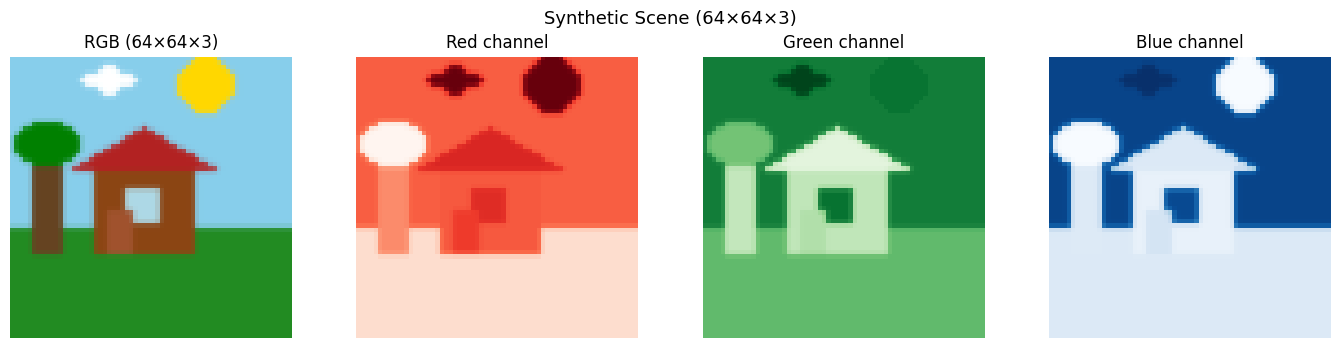

In [3]:
def make_scene_image(size: int = 64) -> np.ndarray:
    """Generate a colorful synthetic scene with geometric shapes."""
    img = Image.new("RGB", (size, size), (135, 206, 235))  # sky blue
    draw = ImageDraw.Draw(img)
    s = size

    # Ground
    draw.rectangle([0, int(0.62 * s), s, s], fill=(34, 139, 34))

    # Sun
    sx, sy, sr = int(0.7 * s), int(0.1 * s), int(0.1 * s)
    draw.ellipse([sx - sr, sy - sr, sx + sr, sy + sr], fill=(255, 215, 0))

    # House body
    hx1, hy1, hx2, hy2 = int(0.3 * s), int(0.4 * s), int(0.65 * s), int(0.7 * s)
    draw.rectangle([hx1, hy1, hx2, hy2], fill=(139, 69, 19))
    # Roof
    mid_x = (hx1 + hx2) // 2
    draw.polygon([(hx1 - 5, hy1), (mid_x, int(0.25 * s)), (hx2 + 5, hy1)], fill=(178, 34, 34))
    # Window
    wx1, wy1 = int(0.42 * s), int(0.48 * s)
    wx2, wy2 = int(0.53 * s), int(0.58 * s)
    draw.rectangle([wx1, wy1, wx2, wy2], fill=(173, 216, 230))
    # Door
    dx1, dy1 = int(0.35 * s), int(0.55 * s)
    dx2, dy2 = int(0.43 * s), int(0.7 * s)
    draw.rectangle([dx1, dy1, dx2, dy2], fill=(160, 82, 45))

    # Tree
    tx1, ty1, tx2, ty2 = int(0.08 * s), int(0.35 * s), int(0.18 * s), int(0.7 * s)
    draw.rectangle([tx1, ty1, tx2, ty2], fill=(101, 67, 33))
    tr = int(0.12 * s)
    tc = (tx1 + tx2) // 2
    draw.ellipse([tc - tr, ty1 - tr, tc + tr, ty1 + int(0.3 * tr)], fill=(0, 128, 0))

    # Cloud
    cx, cy = int(0.35 * s), int(0.08 * s)
    cr = int(0.06 * s)
    draw.ellipse([cx - cr, cy - cr, cx + cr, cy + cr], fill=(255, 255, 255))
    draw.ellipse([cx - 2 * cr, cy - cr // 2, cx, cy + cr // 2], fill=(255, 255, 255))
    draw.ellipse([cx, cy - cr // 2, cx + 2 * cr, cy + cr // 2], fill=(255, 255, 255))

    # Slight blur for smoother look
    img = img.filter(ImageFilter.GaussianBlur(0.5))

    return np.asarray(img, dtype=np.float64) / 255.0


IMG_SIZE = 64
Y_image = make_scene_image(IMG_SIZE)

print(f"Image tensor shape : {Y_image.shape}")
print(f"Value range        : [{Y_image.min():.3f}, {Y_image.max():.3f}]")
print(f"Tensor order       : {Y_image.ndim} (rows × columns × RGB)")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
axes[0].imshow(Y_image)
axes[0].set_title(f"RGB ({IMG_SIZE}×{IMG_SIZE}×3)")
axes[0].axis("off")

for ch, (name, cmap) in enumerate([("Red", "Reds"), ("Green", "Greens"), ("Blue", "Blues")]):
    axes[ch + 1].imshow(Y_image[:, :, ch], cmap=cmap, vmin=0, vmax=1)
    axes[ch + 1].set_title(f"{name} channel")
    axes[ch + 1].axis("off")

plt.suptitle("Synthetic Scene (64×64×3)", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Build DCT + Symlet-4 Wavelet Packet Dictionaries

Following the T-LARS paper, each spatial dictionary is the **column-wise
concatenation** of:
1. A **DCT-II** basis ($n \times n$, orthonormal)
2. A **Wavelet Packet** basis using **Symlet-4** at level 3 ($n \times n$)

This produces a **2× overcomplete** dictionary of shape $(n, 2n)$.  All
columns are $\ell_2$-normalised.

For the **RGB channel mode** we use the $3 \times 3$ identity matrix
(no overcompleteness).

In [4]:
def build_dct_dictionary(n: int) -> np.ndarray:
    """Build a column-normalised DCT-II dictionary of shape (n, n)."""
    i = np.arange(n).reshape(-1, 1)
    j = np.arange(n).reshape(1, -1)
    D = np.cos(np.pi * (2 * i + 1) * j / (2 * n))
    norms = np.linalg.norm(D, axis=0, keepdims=True)
    norms[norms == 0] = 1.0
    return D / norms


def build_wavelet_packet_dictionary(
    n: int, wavelet: str = "sym4", level: int = 3
) -> np.ndarray:
    """Build a wavelet packet dictionary of shape (n, n).

    Each atom is the reconstruction of a single wavelet packet coefficient
    set to 1, matching MATLAB's ``wmpdictionary(n, 'lstcpt', {wavelet, level})``.

    Parameters
    ----------
    n : int
        Signal length.
    wavelet : str
        Wavelet name (default ``'sym4'`` = Symlet with 4 vanishing moments).
    level : int
        Decomposition level (default 3).
    """
    # Discover the nodes at the target level using a zero signal
    wp = pywt.WaveletPacket(
        data=np.zeros(n), wavelet=wavelet, maxlevel=level, mode="periodization"
    )
    nodes = [node.path for node in wp.get_level(level, order="freq")]
    n_coeffs = len(wp[nodes[0]].data)

    atoms = []
    for path in nodes:
        for k in range(n_coeffs):
            # Place a single unit impulse at position k in subband `path`
            wp2 = pywt.WaveletPacket(
                data=None, wavelet=wavelet, maxlevel=level, mode="periodization"
            )
            for p in nodes:
                wp2[p] = np.zeros(n_coeffs)
            wp2[path] = np.zeros(n_coeffs)
            wp2[path].data[k] = 1.0
            atom = wp2.reconstruct(update=False)[:n]
            atoms.append(atom)

    W = np.column_stack(atoms)
    norms = np.linalg.norm(W, axis=0, keepdims=True)
    norms[norms == 0] = 1.0
    return W / norms


def build_dct_wavelet_dictionary(
    n: int, wavelet: str = "sym4", level: int = 3
) -> np.ndarray:
    """Concatenated DCT + Wavelet Packet dictionary, shape (n, 2n).

    Matches the overcomplete dictionary from the T-LARS paper:
    ``normc([DCT | WP(sym4, 3)])``.
    """
    D_dct = build_dct_dictionary(n)
    D_wav = build_wavelet_packet_dictionary(n, wavelet=wavelet, level=level)
    D = np.hstack([D_dct, D_wav])
    norms = np.linalg.norm(D, axis=0, keepdims=True)
    norms[norms == 0] = 1.0
    return D / norms


# ── Build the three factor dictionaries ────────────────────────────
M, N, C = Y_image.shape       # 128, 128, 3

D1 = build_dct_wavelet_dictionary(M)   # (128, 256) — row dictionary
D2 = build_dct_wavelet_dictionary(N)   # (128, 256) — column dictionary
D3 = np.eye(C)                         # (3, 3)     — channel dictionary

total_atoms = D1.shape[1] * D2.shape[1] * D3.shape[1]
print(f"D1 (rows)     : {D1.shape}  — DCT + WP(sym4, 3)")
print(f"D2 (columns)  : {D2.shape}  — DCT + WP(sym4, 3)")
print(f"D3 (channels) : {D3.shape}  — Identity")
print(f"Total Kronecker atoms  : {total_atoms:,}")
print(f"Overcompleteness       : {total_atoms / Y_image.size:.1f}×")

D1 (rows)     : (64, 128)  — DCT + WP(sym4, 3)
D2 (columns)  : (64, 128)  — DCT + WP(sym4, 3)
D3 (channels) : (3, 3)  — Identity
Total Kronecker atoms  : 49,152
Overcompleteness       : 4.0×


### Visualise Dictionary Atoms

Each pair of columns from $D_1$ and $D_2$ forms a **rank-1** spatial atom
via outer product.  Below we show representative atoms from both the DCT
and wavelet packet sub-dictionaries.

In [ ]:
# Show sample DCT atoms and wavelet atoms
fig, axes = plt.subplots(2, 6, figsize=(14, 5))

# Top row: DCT atoms (indices 0..5 are low-frequency DCT)
for idx in range(6):
    atom_2d = np.outer(D1[:, idx], D2[:, idx])
    axes[0, idx].imshow(atom_2d, cmap="RdBu_r", vmin=-0.02, vmax=0.02)
    axes[0, idx].set_title(f"DCT atom {idx}", fontsize=8)
    axes[0, idx].axis("off")
axes[0, 0].set_ylabel("DCT", fontsize=10)

# Bottom row: Wavelet packet atoms (start at column M = 128)
wp_start = M  # wavelet atoms start after DCT columns
for idx in range(6):
    col = wp_start + idx * (M // 6)
    atom_2d = np.outer(D1[:, col], D2[:, col])
    axes[1, idx].imshow(atom_2d, cmap="RdBu_r", vmin=-0.02, vmax=0.02)
    axes[1, idx].set_title(f"WP atom {col}", fontsize=8)
    axes[1, idx].axis("off")
axes[1, 0].set_ylabel("Wavelet", fontsize=10)

fig.suptitle("Sample Dictionary Atoms (rank-1 outer products)", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Per-Iteration Reconstruction Helper

We simulate per-iteration snapshots by running T-LARS with increasing
iteration budgets.  Each snapshot reconstructs the current 3-D image
estimate and displays it inline.

In [ ]:
class IterativeReconstructor:
    """Run T-LARS at successive iteration checkpoints and display 3-D RGB snapshots."""

    def __init__(
        self,
        factor_matrices: List[np.ndarray],
        Y: np.ndarray,
        checkpoints: List[int],
        **tlars_kwargs,
    ) -> None:
        self.factor_matrices = factor_matrices
        self.Y = Y
        self.checkpoints = sorted(checkpoints)
        self.tlars_kwargs = tlars_kwargs
        self.snapshots: List[dict] = []

    def run(self, live_display: bool = True) -> List[dict]:
        """Execute T-LARS at every checkpoint and collect snapshots."""
        self.snapshots.clear()

        for n_iter in self.checkpoints:
            model = TLARS(
                iterations=n_iter,
                tolerance=1e-15,
                debug_mode=True,
                **self.tlars_kwargs,
            )
            model.fit(self.factor_matrices, self.Y)

            Y_hat = np.clip(np.array(model.predict(self.factor_matrices)), 0, 1)
            residual = float(model.norm_r_[-1])
            n_active = len(model.active_columns_)

            snapshot = {
                "iter": model.n_iter_,
                "n_active": n_active,
                "residual_norm": residual,
                "image": Y_hat,
            }
            self.snapshots.append(snapshot)

            print(
                f"[checkpoint] iter={model.n_iter_:>4d}  |  "
                f"active={n_active:>4d}  |  "
                f"||r||={residual:.6f}"
            )

            if live_display:
                ipy_display.clear_output(wait=True)
                fig, axes = plt.subplots(1, 2, figsize=(8, 4))
                axes[0].imshow(self.Y)
                axes[0].set_title("Original")
                axes[0].axis("off")

                axes[1].imshow(Y_hat)
                axes[1].set_title(
                    f"Iter {model.n_iter_} — {n_active} coeffs — ||r||={residual:.4f}"
                )
                axes[1].axis("off")
                plt.tight_layout()
                plt.show()

        return self.snapshots


print("IterativeReconstructor defined ✓")

## 6. Run T-LARS — Watch the Image Emerge

We run the solver at **12 checkpoints** from 1 to 5 000 iterations so that
5–10 % of the dictionary atoms become active — enough for a visually
faithful reconstruction.  The 3-D tensor ($64 \times 64 \times 3$) is
reconstructed using the concatenated DCT + Wavelet Packet dictionaries.

> **Tip:** In a live Jupyter session the image updates in-place.  In a
> static render you will see only the final pair.

In [ ]:
checkpoints = [1, 5, 10, 50, 100, 250, 500, 1000, 1500, 2500, 3500, 5000]

reconstructor = IterativeReconstructor(
    factor_matrices=[D1, D2, D3],
    Y=Y_image,
    checkpoints=checkpoints,
)

snapshots = reconstructor.run(live_display=True)

### Snapshot Gallery

A grid view of all captured checkpoints.

In [ ]:
n_snaps = len(snapshots)
cols = min(n_snaps, 6)
rows = (n_snaps + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.8))
axes_flat = np.array(axes).flatten() if n_snaps > 1 else [axes]

for idx, (ax, snap) in enumerate(zip(axes_flat, snapshots)):
    ax.imshow(snap["image"])
    ax.set_title(
        f"iter {snap['iter']}\n{snap['n_active']} coeffs",
        fontsize=8,
    )
    ax.axis("off")

for ax in axes_flat[n_snaps:]:
    ax.axis("off")

fig.suptitle("T-LARS 3-D Reconstruction Progression", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Analyse the Sparse Coefficient Path

1. **Residual norm vs iteration** — how quickly the algorithm converges.
2. **Number of active coefficients** — the sparsity of the solution.
3. **Final reconstruction error** (MSE, PSNR).

In [ ]:
def compute_psnr(original: np.ndarray, reconstructed: np.ndarray, max_val: float = 1.0) -> float:
    """Compute Peak Signal-to-Noise Ratio (dB) between two tensors."""
    mse = np.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float("inf")
    return float(10 * np.log10(max_val ** 2 / mse))


# ── Convergence plot ──────────────────────────────────────────────
iters   = [s["iter"] for s in snapshots]
resids  = [s["residual_norm"] for s in snapshots]
actives = [s["n_active"] for s in snapshots]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogy(iters, resids, "o-", color="steelblue", linewidth=2)
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Residual Norm ||r||")
ax1.set_title("Convergence Curve")
ax1.grid(True, which="both", linewidth=0.3)

ax2.plot(iters, actives, "s-", color="darkorange", linewidth=2)
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Active Coefficients")
ax2.set_title("Sparsity vs Iteration")
ax2.grid(True, linewidth=0.3)

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────
final = snapshots[-1]
mse_val = float(np.mean((Y_image - final["image"]) ** 2))
psnr_val = compute_psnr(Y_image, final["image"])

print("┌──────────────────────────────────────────┐")
print(f"│ Final iteration         : {final['iter']:>10d}     │")
print(f"│ Active coefficients     : {final['n_active']:>10d}     │")
print(f"│ Total dictionary atoms  : {total_atoms:>10,}     │")
print(f"│ Sparsity ratio          : {final['n_active'] / total_atoms:>10.2%}     │")
print(f"│ Residual norm           : {final['residual_norm']:>13.6f}  │")
print(f"│ MSE                     : {mse_val:>13.6e}  │")
print(f"│ PSNR                    : {psnr_val:>10.2f} dB   │")
print("└──────────────────────────────────────────┘")

## 8. Compare Final Reconstruction vs Original

In [ ]:
def compare_images(
    original: np.ndarray,
    reconstructed: np.ndarray,
    title: str = "Reconstruction Comparison",
) -> None:
    """Display original, reconstructed, and per-channel error images."""
    reconstructed = np.clip(reconstructed, 0, 1)
    error = np.abs(original - reconstructed)
    mse = float(np.mean((original - reconstructed) ** 2))
    psnr = compute_psnr(original, reconstructed)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(reconstructed)
    axes[1].set_title("Reconstructed")
    axes[1].axis("off")

    # Error magnitude across channels
    error_mag = np.mean(error, axis=2)  # average across RGB
    im = axes[2].imshow(error_mag, cmap="hot", vmin=0, vmax=error_mag.max() or 1e-8)
    axes[2].set_title("Mean Absolute Error")
    axes[2].axis("off")
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"  MSE      = {mse:.6e}")
    print(f"  PSNR     = {psnr:.2f} dB")
    print(f"  Max |err|= {error.max():.6e}")


compare_images(Y_image, snapshots[-1]["image"])

## 9. Edge Cases

### 9a - Noisy RGB image
Add Gaussian noise and see how T-LARS naturally **denoises** via sparsity.

### 9b - Degenerate signals
Test with an all-zero tensor and a constant tensor.

In [ ]:
# ─── 9a: Noisy RGB Image ──────────────────────────────────────────
rng = np.random.default_rng(42)
noise_level = 0.10
Y_noisy = np.clip(Y_image + rng.normal(0, noise_level, Y_image.shape), 0, 1)

model_noisy = TLARS(iterations=2000, tolerance=noise_level, debug_mode=True)
model_noisy.fit([D1, D2, D3], Y_noisy)
Y_noisy_hat = np.clip(np.array(model_noisy.predict([D1, D2, D3])), 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(Y_image)
axes[0].set_title("Original (clean)")
axes[0].axis("off")
axes[1].imshow(Y_noisy)
axes[1].set_title(f"Noisy (σ={noise_level})")
axes[1].axis("off")
axes[2].imshow(Y_noisy_hat)
axes[2].set_title(f"T-LARS denoised ({len(model_noisy.active_columns_)} coeffs)")
axes[2].axis("off")
plt.suptitle("Edge Case 9a: Noisy RGB Image Recovery", fontsize=13)
plt.tight_layout()
plt.show()

psnr_noisy_input = compute_psnr(Y_image, Y_noisy)
psnr_noisy_recon = compute_psnr(Y_image, Y_noisy_hat)
print(f"  PSNR (noisy input vs clean)   : {psnr_noisy_input:.2f} dB")
print(f"  PSNR (T-LARS output vs clean) : {psnr_noisy_recon:.2f} dB")
print(f"  Denoising improvement         : {psnr_noisy_recon - psnr_noisy_input:+.2f} dB")

In [ ]:
# --- 9b: Degenerate Signals ---
# All-zero tensor
Y_zero = np.zeros((M, N, C))
model_zero = TLARS(iterations=10, tolerance=0.01, debug_mode=True)
model_zero.fit([D1, D2, D3], Y_zero)
print(f"All-zero tensor -> active coefficients: {len(model_zero.active_columns_)}")
print(f"                  final ||r||: {model_zero.norm_r_[-1]:.6f}")

# Constant tensor
Y_const = np.full((M, N, C), 0.5)
model_const = TLARS(iterations=50, tolerance=0.001, debug_mode=True)
model_const.fit([D1, D2, D3], Y_const)
Y_const_hat = np.clip(np.array(model_const.predict([D1, D2, D3])), 0, 1)
print(f"\nConstant tensor -> active coefficients: {len(model_const.active_columns_)}")
print(f"                  PSNR: {compute_psnr(Y_const, Y_const_hat):.2f} dB")

## 10. Advanced Usage

### 10a - L0 vs L1 mode
L0 mode uses greedy forward selection (never removes columns) while L1
follows the full LARS/LASSO path.

### 10b - Parameter introspection
Demonstrate `get_params` / `set_params` (scikit-learn-style API).

In [ ]:
# ─── 10a: L0 vs L1 Mode ──────────────────────────────────────────
results = {}
for mode_name, l0 in [("L1 (LASSO path)", False), ("L0 (greedy)", True)]:
    model = TLARS(iterations=2000, tolerance=0.01, l0_mode=l0, debug_mode=True)
    t0 = time.perf_counter()
    model.fit([D1, D2, D3], Y_image)
    elapsed = time.perf_counter() - t0
    Y_hat = np.clip(np.array(model.predict([D1, D2, D3])), 0, 1)
    psnr = compute_psnr(Y_image, Y_hat)
    results[mode_name] = {
        "n_iter": model.n_iter_,
        "n_active": len(model.active_columns_),
        "psnr": psnr,
        "time": elapsed,
    }
    print(f"{mode_name:>20s}  →  {model.n_iter_:>4d} iters, "
          f"{len(model.active_columns_):>4d} coeffs, "
          f"PSNR={psnr:.2f} dB, {elapsed:.3f}s")

# ── Bar chart comparison ─────────────────────────────────────────
labels = list(results.keys())
psnrs  = [results[k]["psnr"] for k in labels]
n_acts = [results[k]["n_active"] for k in labels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
bars1 = ax1.bar(labels, psnrs, color=["steelblue", "darkorange"])
ax1.set_ylabel("PSNR (dB)")
ax1.set_title("Reconstruction Quality")
for bar, val in zip(bars1, psnrs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}", ha="center", fontsize=10)

bars2 = ax2.bar(labels, n_acts, color=["steelblue", "darkorange"])
ax2.set_ylabel("Active Coefficients")
ax2.set_title("Sparsity")
for bar, val in zip(bars2, n_acts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha="center", fontsize=10)

plt.suptitle("L1 (LASSO) vs L0 (Greedy) Mode", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ─── 10b: Parameter Introspection ─────────────────────────────────
model = TLARS(tolerance=0.05, l0_mode=True, iterations=500)

# get_params — returns all current parameters
print("get_params():")
for k, v in model.get_params().items():
    print(f"  {k:>22s} = {v!r}")

# set_params — update parameters (scikit-learn style)
model.set_params(tolerance=0.01, l0_mode=False)
print("\nAfter set_params(tolerance=0.01, l0_mode=False):")
print(f"  tolerance = {model.config.tolerance}")
print(f"  l0_mode   = {model.config.l0_mode}")